In [2]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

df_white = pd.read_csv('winequality-white.csv', sep=';')

X = df_white.drop('quality', axis=1)
y = df_white['quality']


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


n_features = X.shape[1]
pca = PCA(n_components=n_features - 2)
X_pca = pca.fit_transform(X_scaled)

explained_variance = pca.explained_variance_ratio_.sum()

print(f"Oryginalna liczba cech: {n_features}")
print(f"Liczba cech po redukcji: {X_pca.shape[1]}")
print(f"Wyjaśniona wariancja: {explained_variance:.4f} ({explained_variance*100:.2f}%)")

Oryginalna liczba cech: 11
Liczba cech po redukcji: 9
Wyjaśniona wariancja: 0.9718 (97.18%)


In [3]:
from sklearn.decomposition import PCA


pca_95 = PCA(n_components=0.95)

X_pca_95 = pca_95.fit_transform(X_scaled)

n_components_kept = pca_95.n_components_
total_variance = pca_95.explained_variance_ratio_.sum()

print(f"Liczba cech potrzebna do zachowania 95% wariancji: {n_components_kept}")
print(f"Dokładna wyjaśniona wariancja: {total_variance:.4f}")

Liczba cech potrzebna do zachowania 95% wariancji: 9
Dokładna wyjaśniona wariancja: 0.9718


Średnie Accuracy po 10 próbach:
Brak PCA (Baseline)      : 0.5516
PCA (o 2 mniej)          : 0.5584
PCA (95% wariancji)      : 0.5584


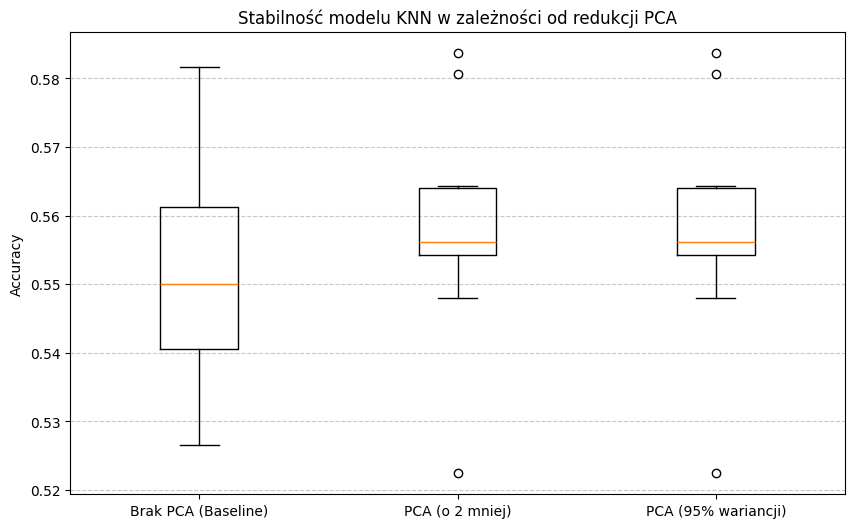

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

n_runs = 10
results = {
    "Brak PCA (Baseline)": [],
    "PCA (o 2 mniej)": [],
    "PCA (95% wariancji)": []
}

for i in range(n_runs):
    # Losowy podział w każdej iteracji
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=i)

    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc = scaler.transform(X_test)

    # --- SCENARIUSZ A: Brak PCA ---
    knn = KNeighborsClassifier()
    knn.fit(X_train_sc, y_train)
    results["Brak PCA (Baseline)"].append(accuracy_score(y_test, knn.predict(X_test_sc)))

    # --- SCENARIUSZ B: PCA (-2 cechy) ---
    pca_b = PCA(n_components=X.shape[1] - 2)
    X_train_pca_b = pca_b.fit_transform(X_train_sc)
    X_test_pca_b = pca_b.transform(X_test_sc)

    knn.fit(X_train_pca_b, y_train)
    results["PCA (o 2 mniej)"].append(accuracy_score(y_test, knn.predict(X_test_pca_b)))

    # --- SCENARIUSZ C: PCA (95% wariancji) ---
    pca_c = PCA(n_components=0.95)
    X_train_pca_c = pca_c.fit_transform(X_train_sc)
    X_test_pca_c = pca_c.transform(X_test_sc)

    knn.fit(X_train_pca_c, y_train)
    results["PCA (95% wariancji)"].append(accuracy_score(y_test, knn.predict(X_test_pca_c)))

print("Średnie Accuracy po 10 próbach:")
for key, values in results.items():
    print(f"{key:25}: {np.mean(values):.4f}")

plt.figure(figsize=(10, 6))
plt.boxplot(results.values(), tick_labels=results.keys())
plt.ylabel('Accuracy')
plt.title('Stabilność modelu KNN w zależności od redukcji PCA')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()